# NISAR DEM

In [1]:
import os
import time
from pathlib import Path

import requests
import numpy as np
import rasterio
from rasterio.windows import from_bounds
import matplotlib.pyplot as plt

In [2]:
# --- DEM version + projection directory ---
DEM_VERSION = "v1.2"
EPSG_DIR = "EPSG4326"   # or "EPSG3413" (Arctic), "EPSG3031" (Antarctic)

# --- AOI bbox ---
# For EPSG4326: lon/lat bbox (min_lon, min_lat, max_lon, max_lat)
minx, miny, maxx, maxy = -116.7, 35.9, -116.6, 36.0
BBOX = (minx, miny, maxx, maxy)

# --- ASF HTTPS VRT ---
ASF_HTTP_BASE = "https://nisar.asf.earthdatacloud.nasa.gov/NISAR/DEM"
HTTP_VRT_URL = f"{ASF_HTTP_BASE}/{DEM_VERSION}/{EPSG_DIR}/{EPSG_DIR}.vrt"
HTTP_VRT_VSI = f"/vsicurl/{HTTP_VRT_URL}"

# --- ASF S3 VRT ---
ASF_S3_BUCKET = "sds-n-cumulus-prod-nisar-products"
S3_KEY = f"DEM/{DEM_VERSION}/{EPSG_DIR}/{EPSG_DIR}.vrt"
S3_VRT_S3URI = f"s3://{ASF_S3_BUCKET}/{S3_KEY}"
S3_VRT_VSI = f"/vsis3/{ASF_S3_BUCKET}/{S3_KEY}"

HTTP_VRT_URL, S3_VRT_S3URI

('https://nisar.asf.earthdatacloud.nasa.gov/NISAR/DEM/v1.2/EPSG4326/EPSG4326.vrt',
 's3://sds-n-cumulus-prod-nisar-products/DEM/v1.2/EPSG4326/EPSG4326.vrt')

#  HTTP workflow

In [3]:
def subset_to_geotiff(dataset_path: str, bbox, out_tif: str):
    minx, miny, maxx, maxy = bbox

    with rasterio.open(dataset_path) as src:
        win = from_bounds(minx, miny, maxx, maxy, transform=src.transform)
        data = src.read(1, window=win)
        new_transform = src.window_transform(win)

        profile = src.profile.copy()
        profile.update(
            driver="GTiff",
            height=data.shape[0],
            width=data.shape[1],
            transform=new_transform,
            tiled=True,
            compress="deflate",
            BIGTIFF="IF_SAFER",
        )

        with rasterio.open(out_tif, "w", **profile) as dst:
            dst.write(data, 1)

    return out_tif

In [4]:
def probe_http_no_redirect(url: str, timeout=20):
    r = requests.get(url, allow_redirects=False, timeout=timeout)
    return {
        "status": r.status_code,
        "location": r.headers.get("Location"),
        "content_type": r.headers.get("content-type"),
        "head": r.text[:120],
    }

probe = probe_http_no_redirect(HTTP_VRT_URL)
probe

{'status': 302,
 'location': 'https://urs.earthdata.nasa.gov/oauth/authorize?client_id=qpa3q_b7OJ32gGjwA9DxHg&response_type=code&redirect_uri=https://nisar.asf.earthdatacloud.nasa.gov/login&state=%2FNISAR%2FDEM%2Fv1.2%2FEPSG4326%2FEPSG4326.vrt&app_type=401',
 'content_type': 'application/json',
 'head': ''}

In [10]:
out_http = "dem_subset_http.tif"

if probe.get("status") == 200 and str(probe.get("head","")).lstrip().startswith("<VRTDataset"):
    try:
        subset_to_geotiff(HTTP_VRT_VSI, BBOX, out_http)
        print("HTTP subset wrote:", out_http)
    except Exception as e:
        print("HTTP subset failed:", type(e).__name__, e)
else:
    print("HTTP workflow not usable")

HTTP workflow not usable


# S3 workflow

In [6]:
import earthaccess

ASF_S3CREDS_ENDPOINT = "https://nisar.asf.earthdatacloud.nasa.gov/s3credentials"

creds = None
for attempt in range(1, 6):
    try:
        auth = earthaccess.login()  # uses .netrc or prompts
        creds = auth.get_s3_credentials(endpoint=ASF_S3CREDS_ENDPOINT)
        print(f"Got S3 creds on attempt {attempt}")
        break
    except Exception as e:
        print(f"Attempt {attempt} failed:", type(e).__name__, e)
        time.sleep(5)

if creds is None:
    raise RuntimeError("Could not obtain ASF S3 creds via Earthdata Login. Try again later or use browser-based /s3credentials.")

Got S3 creds on attempt 1


In [7]:
os.environ["AWS_ACCESS_KEY_ID"] = creds["accessKeyId"]
os.environ["AWS_SECRET_ACCESS_KEY"] = creds["secretAccessKey"]
os.environ["AWS_SESSION_TOKEN"] = creds["sessionToken"]


os.environ["AWS_REGION"] = "us-west-2"
os.environ["AWS_DEFAULT_REGION"] = "us-west-2"


os.environ["AWS_REQUEST_PAYER"] = "requester"
os.environ["CPL_AWS_REQUEST_PAYER"] = "requester"

print("AWS_* env vars set.")
print("S3 VRT:", S3_VRT_S3URI)

AWS_* env vars set.
S3 VRT: s3://sds-n-cumulus-prod-nisar-products/DEM/v1.2/EPSG4326/EPSG4326.vrt


In [8]:
out_s3 = "dem_subset_s3.tif"

try:
    subset_to_geotiff(S3_VRT_VSI, BBOX, out_s3)
    print("S3 subset wrote:", out_s3)
except Exception as e:
    print("S3 subset failed:", type(e).__name__, e)
    raise

S3 subset wrote: dem_subset_s3.tif


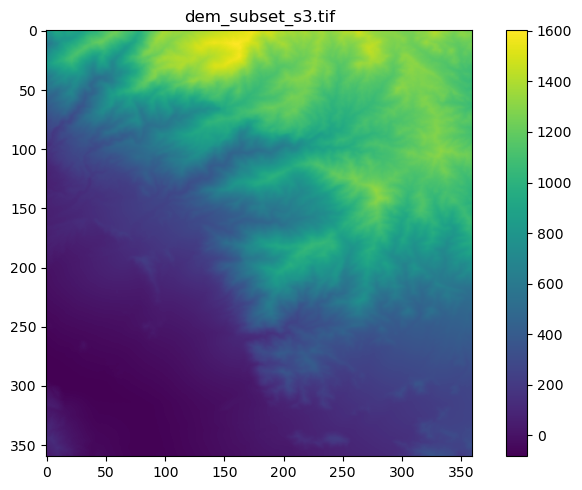

In [9]:
if Path(out_s3).exists():
    with rasterio.open(out_s3) as src:
        arr = src.read(1)
        nodata = src.nodata

    if nodata is not None:
        arr = np.where(arr == nodata, np.nan, arr)

    plt.figure(figsize=(7, 5))
    plt.imshow(arr)
    plt.title(out_s3)
    plt.colorbar()
    plt.tight_layout()
    plt.show()